You have at your disposal 100000 images of human faces, and their occlusion label.
The goal of this challenge is to regress the percentage of the face that is occluded.
We also want to have similar performances on female and male, the gender label is given for the train database

Below is the formula of the evaluation score

$$
 Err = \frac{\sum_{i}{w_i(p_i - GT_i)^2}}{\sum_{i}{w_i}}, w_i = \frac{1}{30} + GT_i
$$

$$
Score = \frac{Err_F + Err_M}{2} + \left | Err_F - Err_M \right |
$$

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split

### Load dataframes

In [2]:
df_train = pd.read_csv("occlusion_datasets/train.csv", delimiter=',')
df_test = pd.read_csv("occlusion_datasets/test_students.csv", delimiter=',')

image_dir = "images/Crop_224_5fp_100K"

In [3]:
df_train.head()

,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [4]:
df_test.head()

,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


#### Remove nan values

In [5]:
df_train = df_train.dropna()
df_test = df_test.dropna()

### Split Dataframe in train and val

In [6]:
# df_val = df_train.loc[:20000].reset_index()
# df_train = df_train.loc[20000:].reset_index()

# 1. Création de "catégories" d'occlusion (Low, Medium, High) pour pouvoir stratifier
# Car on ne peut pas stratifier directement sur une valeur continue.
bins = [-0.01, 0.1, 0.3, 1.0] # Les seuils (visuels d'après l'histogramme du PDF)
labels = ['Low', 'Med', 'High']
df_train['occ_bin'] = pd.cut(df_train['FaceOcclusion'], bins=bins, labels=labels)

# 2. Création d'une clé de stratification combinée : Genre + Niveau d'occlusion
df_train['stratify_key'] = df_train['gender'].astype(str) + "_" + df_train['occ_bin'].astype(str)

# 3. Le vrai découpage (80% Train, 20% Val)
# random_state=42 garantit la reproductibilité (exigée par le jury)
train_split, val_split = train_test_split(
    df_train, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_train['stratify_key']
)

# 4. Nettoyage : on enlève nos colonnes temporaires et on réinitialise l'index
df_train = train_split.drop(columns=['occ_bin', 'stratify_key']).reset_index(drop=True)
df_val = val_split.drop(columns=['occ_bin', 'stratify_key']).reset_index(drop=True)

print(f"Taille Train: {len(df_train)} | Taille Val: {len(df_val)}")

Taille Train: 80000 | Taille Val: 20000


In [7]:
len(df_train), len(df_val), len(df_test)

(80000, 20000, 29980)

### Check that all images are read correctly

In [8]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    try:
        filename = df_train.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

for idx, row in tqdm(df_val.iterrows(), total=len(df_val)):
    try:
        filename = df_val.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)
        
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        filename = df_test.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

100%|██████████| 29980/29980 [00:07<00:00, 3776.45it/s]


### Display random images

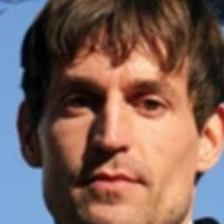

database3/database3/m.027x65s/101-FaceId-0_align.webp 0.188491 1.0


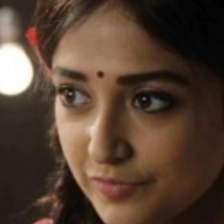

database3/database3/m.01x1dmq/32-FaceId-0_align.webp 0.124654 0.0


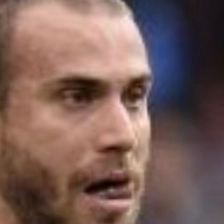

database3/database3/m.0261qhw/80-FaceId-0_align.webp 0.000871 1.0


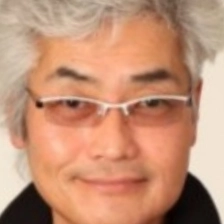

database3/database3/m.01wvydk/3-FaceId-0_align.webp 0.084083 1.0


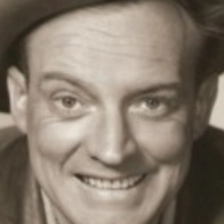

database3/database3/m.014kg4/20-FaceId-0_align.webp 0.009231 1.0


In [9]:
for idx, row in df_train.sample(frac=1)[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

### Make Dataset and Dataloader

In [10]:
# class Dataset(torch.utils.data.Dataset):
#     'Characterizes a dataset for PyTorch'
#     def __init__(self, df, image_dir, training=True):
#          'Initialization'
#          self.training = training
#          self.image_dir = image_dir
#          self.df = df
#          self.transform = transforms.ToTensor()
         
#     def __len__(self):
#         'Denotes the total number of samples'
#         return len(self.df)

#     def __getitem__(self, index):
#         'Generates one sample of data'
#         # Select sample
#         row = self.df.loc[index]
#         filename = row['filename']

#         # Load data and get label
#         img = Image.open(f"{image_dir}/{filename}")

#         X = self.transform(img)

#         if self.training:
#             y = row['FaceOcclusion']
#             y = np.float32(y)
#             gender = row['gender']
#             return X, y, gender, filename
#         else:
#             y = None
#             gender = None
#             return X, filename


# 1. Définir les transformations (Augmentation + Normalisation ImageNet)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Légères variations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pour la validation et le test, JAMAIS de Data Augmentation, juste la normalisation !
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Mise à jour de la classe Dataset
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df, image_dir, transform=None, training=True):
         self.training = training
         self.image_dir = image_dir
         self.df = df
         self.transform = transform 
         
    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.loc[index]
        filename = row['filename']
        
        # .convert('RGB') est une sécurité au cas où certaines images soient en niveaux de gris
        img = Image.open(f"{self.image_dir}/{filename}").convert('RGB') 

        if self.transform:
            X = self.transform(img)

        if self.training:
            y = np.float32(row['FaceOcclusion'])
            gender = row['gender']
            return X, y, gender, filename
        else:
            return X, filename

# 3. Instanciation des nouveaux Datasets
training_set = Dataset(df_train, image_dir, transform=train_transforms, training=True)
# Attention : training=True pour validation_set car on a besoin de lire les labels pour évaluer !
validation_set = Dataset(df_val, image_dir, transform=val_transforms, training=True) 
test_set = Dataset(df_test, image_dir, transform=val_transforms, training=False)

# 4. (Optionnel) Recréer les DataLoaders avec un batch_size adapté à ton GPU
params_train = {'batch_size': 32, 'shuffle': True, 'num_workers': 0}
params_val = {'batch_size': 32, 'shuffle': False, 'num_workers': 0}

training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
test_generator = torch.utils.data.DataLoader(test_set, **params_val)

In [ ]:
# training_set = Dataset(df_train, image_dir)
# validation_set = Dataset(df_val, image_dir)
# test_set = Dataset(df_test, image_dir, training=False)

# params_train = {'batch_size': 64,
#           'shuffle': True,
#           'num_workers': 4}

# params_val = {'batch_size': 64,
#           'shuffle': False,
#           'num_workers': 4}

# training_generator = torch.utils.data.DataLoader(training_set, **params_train)
# validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
# test_generator = torch.utils.data.DataLoader(test_set, **params_val)

### Create naive model

In [11]:
from torchvision.models import mobilenet_v3_small
model = torchvision.models.mobilenet_v3_small(num_classes=1)
model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

#### Count number of parameters

In [12]:
from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_trainable_params = 0
    total_params = 0
    for name, parameter in model.named_parameters():
        params = parameter.numel()
        total_params += params
        if not parameter.requires_grad:
            continue
        table.add_row([name, params])
        total_trainable_params += params
    print(table)
    print(f"Total Trainable Params: {total_trainable_params}")
    print(f"Total Params: {total_params}")
    
count_parameters(model)

ModuleNotFoundError: No module named 'prettytable'

### Loss and optimizer

In [13]:
class IdemiaLoss(nn.Module):
    def __init__(self):
        super(IdemiaLoss, self).__init__()
        self.eps = 1e-8 

    def forward(self, preds, targets, genders):
        preds = preds.view(-1)
        targets = targets.view(-1)
        genders = genders.view(-1)

        # 1. Poids
        weights = (1.0 / 30.0) + targets

        # 2. Masques convertis en floats (0.0 ou 1.0) au lieu de booléens (True/False)
        mask_f = (genders == 0.0).float()
        mask_m = (genders == 1.0).float()

        # 3. Calcul de l'erreur Femmes (multiplication par 0 ou 1)
        sum_weights_f = torch.sum(weights * mask_f)
        err_f = torch.sum(mask_f * weights * (preds - targets)**2) / (sum_weights_f + self.eps)

        # 4. Calcul de l'erreur Hommes
        sum_weights_m = torch.sum(weights * mask_m)
        err_m = torch.sum(mask_m * weights * (preds - targets)**2) / (sum_weights_m + self.eps)

        # 5. Score final
        score = (err_f + err_m) / 2.0 + torch.abs(err_f - err_m)
        return score

In [14]:
loss_fn = IdemiaLoss()

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm

# ==========================================
# 1. Configuration du Matériel (Apple M4)
# ==========================================
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 GPU Apple Silicon (MPS) activé !")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("GPU Nvidia (CUDA) activé !")
else:
    device = torch.device("cpu")
    print("⚠️ Attention: Entraînement sur CPU...")

# ==========================================
# 2. Création du modèle EfficientNet-B0
# ==========================================
print("Chargement d'EfficientNet-B0...")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Modification de la tête pour la régression (1 sortie avec Sigmoid)
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=num_ftrs, out_features=1),
    nn.Sigmoid() # Force la prédiction entre 0% et 100%
)

model = model.to(device)

# ==========================================
# 3. Paramètres d'optimisation
# ==========================================
loss_fn = IdemiaLoss() # Notre fameuse loss sur-mesure !
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ==========================================
# 4. Boucle d'entraînement (Test de bout en bout)
# ==========================================
num_epochs = 1
print("\n🔥 Démarrage de l'entraînement optimisé...")

model.train()

for epoch in range(num_epochs):
    print(f"--- Epoch {epoch+1}/{num_epochs} ---")
    
    pbar = tqdm(enumerate(training_generator), total=len(training_generator))
    
    for batch_idx, (X, y, gender, filename) in pbar:
        # non_blocking=True permet d'envoyer les données au GPU sans bloquer le CPU
        X = X.to(device, non_blocking=True)
        y = y.to(device, dtype=torch.float32, non_blocking=True)
        gender = gender.to(device, dtype=torch.float32, non_blocking=True)
        
        y_pred = model(X)
        loss = loss_fn(y_pred, y, gender)
        
        if torch.isnan(loss):
            print(f"\n⚠️ Alerte : La loss est NaN au batch {batch_idx}. Arrêt.")
            break
            
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pbar.set_description(f"Loss Idemia: {loss.item():.4f}")
    
    # Nettoyage de la mémoire graphique Apple à la fin de l'époque
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

print("\n✅ Entraînement terminé avec succès !")

🚀 GPU Apple Silicon (MPS) activé !
Chargement d'EfficientNet-B0...

🔥 Démarrage de l'entraînement optimisé...
--- Epoch 1/1 ---


Loss Idemia: 0.0023:  16%|█▌        | 390/2500 [03:15<17:21,  2.03it/s]

In [ ]:
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NameError: name 'model' is not defined

In [ ]:
def evaluate_model(model, val_loader, device):
    print("Évaluation sur le set de validation...")
    model.eval() # Désactive le Dropout
    
    all_preds = []
    all_targets = []
    all_genders = []
    
    # On désactive le calcul du gradient pour aller beaucoup plus vite
    with torch.inference_mode():
        for X, y, gender, _ in tqdm(val_loader, desc="Inférence"):
            X = X.to(device)
            y_pred = model(X).cpu().view(-1) # On ramène sur le CPU proprement
            
            all_preds.append(y_pred)
            all_targets.append(y.view(-1))
            all_genders.append(gender.view(-1))
            
    # Concaténation de toutes les listes en gros tenseurs 1D
    preds = torch.cat(all_preds)
    targets = torch.cat(all_targets)
    genders = torch.cat(all_genders)
    
    # --- Calcul manuel de la métrique d'Idemia sur tout le set ---
    weights = (1.0 / 30.0) + targets
    
    mask_f = (genders == 0.0).float()
    mask_m = (genders == 1.0).float()
    
    err_f = torch.sum(mask_f * weights * (preds - targets)**2) / torch.sum(weights * mask_f)
    err_m = torch.sum(mask_m * weights * (preds - targets)**2) / torch.sum(weights * mask_m)
    
    score_final = (err_f + err_m) / 2.0 + torch.abs(err_f - err_m)
    
    print("\n--- RÉSULTATS DE VALIDATION ---")
    print(f"Erreur Femmes : {err_f.item():.4f}")
    print(f"Erreur Hommes : {err_m.item():.4f}")
    print(f"Pénalité de parité (|F - M|) : {torch.abs(err_f - err_m).item():.4f}")
    print(f"🏆 SCORE FINAL IDEMIA : {score_final.item():.4f}")
    print("-------------------------------")
    
    return score_final.item()

In [ ]:
final_score = evaluate_model(model, validation_generator, device)

### Train naive model

In [ ]:
# On vérifie si le GPU Apple est disponible
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("GPU Apple Silicon (MPS) activé ! 🚀")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("GPU Nvidia (CUDA) activé !")
else:
    device = torch.device("cpu")
    print("Attention: Entraînement sur CPU...")

# On envoie le modèle sur la bonne puce
model = model.to(device)

#### Fit on train split

In [ ]:
num_epochs = 1

for n in range(num_epochs):
    print(f"Epoch {n+1}")
    for batch_idx, (X, y, gender, filename) in (pbar := tqdm(enumerate(training_generator), total=len(training_generator))):
        # On transfère AUSSI le genre sur le GPU
        X = X.to(device)
        y = y.to(device)
        gender = gender.to(device) 
        
        y_pred = model(X)
        
        # On calcule la perte avec nos 3 arguments
        loss = loss_fn(y_pred, y, gender)

        if loss.isnan():
            print("Erreur : Loss is NaN")
            break

        pbar.set_description(f"Loss: {loss.item():.4f}")
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

Epoch 1


Loss: 0.0013: 100%|█████████████████████████| 1250/1250 [02:50<00:00,  7.34it/s]


## Evaluate metric on validation split

In [18]:
def error_fn(df):
    pred = df.loc[:, "pred"]
    ground_truth = df.loc[:, "target"]
    weight = 1/30 + ground_truth

    return np.sum(((pred - ground_truth)**2) * weight, axis=0) / np.sum(weight, axis=0)

def metric_fn(female, male):
    err_male = error_fn(male)
    err_female = error_fn(female)
    return (err_male + err_female) / 2 + abs(err_male - err_female)

In [19]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        for i in range(len(X)):

            results_list.append({'filename': filename[i],
                                 'pred': float(y_pred[i]),
                                  'target': float(y[i]),
                                  'gender': float(gender[i])
                                 })
results_df = pd.DataFrame(results_list)

100%|█████████████████████████████████████████| 313/313 [01:20<00:00,  3.90it/s]


In [20]:
results_df.head()

,filename,pred,target,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.013374,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.033009,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.018109,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.146553,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.266857,0.252091,1.0


<Axes: >

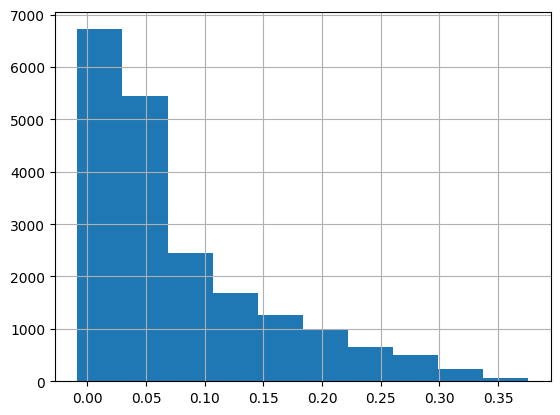

In [21]:
import matplotlib.pyplot as plt
results_df['pred'].hist()


In [22]:
results_male = results_df.loc[results_df["gender"] == 1.0]
results_female = results_df.loc[results_df["gender"] == 0.0]

In [23]:
metric_fn(results_male, results_female)

np.float64(0.00428758396351392)

### Make predictions on test dataset

In [24]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, filename) in tqdm(enumerate(test_generator), total=len(test_generator)):
        X = X.to(device)
        y_pred = model(X)
    
        for i in range(len(X)):
            results_list.append({'filename': filename[i],
                                 'FaceOcclusion': float(y_pred[i]),
                                 })
results_df = pd.DataFrame(results_list)

100%|█████████████████████████████████████████| 469/469 [01:50<00:00,  4.25it/s]


In [25]:
results_df.head()

,filename,FaceOcclusion
0,database3/database3/m.0256vn/81-FaceId-0_align...,0.134231
1,database3/database3/m.01dgwg/29-FaceId-0_align...,0.090508
2,database3/database3/m.02l0nk/72-FaceId-0_align...,0.060727
3,database3/database3/m.026jp3/94-FaceId-1_align...,0.100883
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...,0.107763


### Export predictions
Note: We need to add a dummy 'gender' column for the hfactory upload.

In [26]:
results_df['gender'] = 'x'
results_df.to_csv("test_predictions.csv", sep=',', index=False)